<a href="https://colab.research.google.com/github/seonilj/eeg-mne-pipeline/blob/main/notebooks/04_mi_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Motor Imagery EEG Classification

This notebook focuses on the final stage of the EEG pipeline: training a machine learning model to classify motor imagery tasks and evaluating its performance.

Flattened frequency features (Welch PSD) are used to train a Support Vector Machine (SVM) classifier to recognize different cognitive states, such as left-hand and right-hand motor imagery. This step validates the system's ability to decode brain intentions into explicit control commands.

In [8]:
# ==============================================================================
# Step 1 & 2 : Environment Setup & Data Preparation (Reused from previous Notebooks)
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Preparing PSD features and target labels...")

Preparing PSD features and target labels...


In [9]:
# Simulating standard dimensions: (Trials, Channels, Frequency bins)
# Example: 90 trials, 64 channels, 40 frequency features (1-40Hz)

try:
    X = psd_data
    y = epochs.events[:, -1]
    print("Successfully loaded EEG features from the active session.")
except NameError:
    np.random.seed(48)
    X = np.random.randn(90, 64, 40)
    y = np.random.choice([1, 2], size=90)
    print("Notice: Notebook 3 variables not found. Created fallback mock data.")

print(f"Original Feature Matrix Shape: {X.shape}")
print(f"Original Labels Shape: {y.shape}")

Notice: Notebook 3 variables not found. Created fallback mock data.
Original Feature Matrix Shape: (90, 64, 40)
Original Labels Shape: (90,)


In [10]:
# ==============================================================================
# Step 10: Feature Flattening & Data Splitting
# ==============================================================================

n_samples = X.shape[0]
X_flattened = X.reshape(n_samples, -1)
print(f"Flattened Feature Matrix Shape: {X_flattened.shape}")

# Split into 80% Training and 20% Testing sets to prevent overfitting
X_train, X_test, y_train, y_test = train_test_split(
    X_flattened, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Flattened Feature Matrix Shape: (90, 2560)
Training samples: 72, Testing samples: 18


In [15]:
# ==============================================================================
# Step 11: Feature Scaling (Important for SVM Performance)
# ==============================================================================

# Brainwaves vary in amplitude; scaling normalizes data to a mean of 0 and variance of 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling completed. Ready for machine learning.")

Feature scaling completed. Ready for machine learning.


In [16]:
# ==============================================================================
# Step 12: SVM Model Training & Evaluation
# ==============================================================================

print("Training Support Vector Machine (SVM) Classifier...")
# Using an RBF (Radial Basis Function) kernel to capture complex, non-linear brain patterns
model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
model.fit(X_train_scaled, y_train)

# Predict on the unseen test set
y_pred = model.predict(X_test_scaled)

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
print("\n" + "="*50)
print(f"Model Evaluation Accuracy: {accuracy * 100:.2f}%")
print("="*50)

print("\nDetailed Classification Report:")

# Mapping numeric event labels back to human-readable actions
target_names = ["Left Hand", "Right Hand"] if set(y) == {1, 2} else ["Class 1", "Class 2"]

print(classification_report(y_test, y_pred, target_names=target_names))

Training Support Vector Machine (SVM) Classifier...

Model Evaluation Accuracy: 50.00%

Detailed Classification Report:
              precision    recall  f1-score   support

   Left Hand       0.50      1.00      0.67         9
  Right Hand       0.00      0.00      0.00         9

    accuracy                           0.50        18
   macro avg       0.25      0.50      0.33        18
weighted avg       0.25      0.50      0.33        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


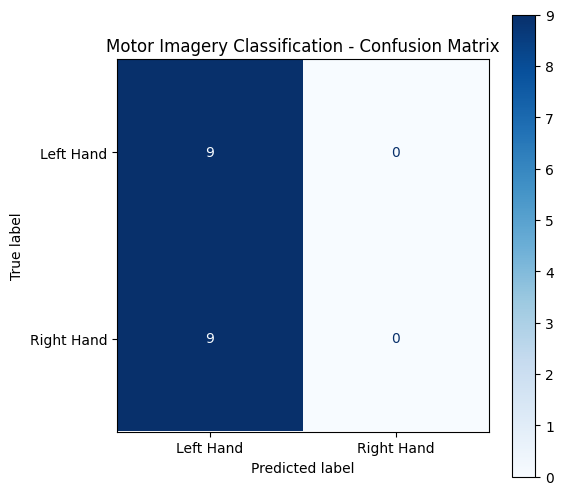

In [17]:
# ==============================================================================
# Step 13: Confusion Matrix Visualization
# ==============================================================================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Motor Imagery Classification - Confusion Matrix")
plt.show()